# 재고지표 산출

재고지표 = 시군구별 용도별 주민등록인구 1인당 연면적

연면적 / 인구


## 산점도


In [20]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter, PercentFormatter

# import auri
plt.style.use("./auri.mplstyle")
pd.options.display.unicode.east_asian_width = True

np.random.seed(1106)


In [87]:
from collections import defaultdict

df = pd.read_csv(
    "output/floor_area_by_sgg_orig_and_use_agg.csv",
    dtype=defaultdict(
        lambda: "Int64", {"시군구_집계단위": "object", "시군구명": "object"}
    ),
    # na_values=["-"],
).set_index("시군구_집계단위")
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 251 entries, 11110 to err
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   시군구명    250 non-null    object
 1   주거용     251 non-null    Int64 
 2   상업용     251 non-null    Int64 
 3   공업용     250 non-null    Int64 
 4   교육및사회용  251 non-null    Int64 
 5   기타      251 non-null    Int64 
dtypes: Int64(5), object(1)
memory usage: 15.0+ KB


In [88]:
s_pop = (
    pd.read_csv(
        "input/주민등록인구_2022.csv",
        dtype={"코드": "object"},
        # na_values=["-"],
    )
    .set_index("코드")["총인구수2022"]
    .str.replace(",", "")
    .astype("Int64")
)
s_pop.info()


<class 'pandas.core.series.Series'>
Index: 251 entries, 전국 to 50130
Series name: 총인구수2022
Non-Null Count  Dtype
--------------  -----
251 non-null    Int64
dtypes: Int64(1)
memory usage: 4.2+ KB


In [89]:
s_pop.head()

코드
전국     51439038
11110      141379
11140      120437
11170      218650
11200      281000
Name: 총인구수2022, dtype: Int64

In [90]:
df2 = df.join(s_pop, how="outer")  # for checking errors

In [91]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 252 entries, 11110 to 전국
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   시군구명      250 non-null    object
 1   주거용       251 non-null    Int64 
 2   상업용       251 non-null    Int64 
 3   공업용       250 non-null    Int64 
 4   교육및사회용    251 non-null    Int64 
 5   기타        251 non-null    Int64 
 6   총인구수2022  251 non-null    Int64 
dtypes: Int64(6), object(1)
memory usage: 17.2+ KB


In [92]:
df2[df2.시군구명.isna()]

,시군구명,주거용,상업용,공업용,교육및사회용,기타,총인구수2022
err,NaN,24704,6995,<NA>,52435,1283,<NA>
전국,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,51439038


In [93]:
df3 = df2[df2.시군구명.notna()]
df3 = df3.rename(columns={"총인구수2022": "주민등록인구"})
df3["연면적_합계"] = df3[["주거용", "상업용", "공업용", "교육및사회용", "기타"]].sum(
    axis=1
)
df3 = df3[
    [
        "시군구명",
        "연면적_합계",
        "주거용",
        "상업용",
        "공업용",
        "교육및사회용",
        "기타",
        "주민등록인구",
    ]
]
df3.info()


<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 11110 to 50130
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   시군구명    250 non-null    object
 1   연면적_합계  250 non-null    Int64 
 2   주거용     250 non-null    Int64 
 3   상업용     250 non-null    Int64 
 4   공업용     250 non-null    Int64 
 5   교육및사회용  250 non-null    Int64 
 6   기타      250 non-null    Int64 
 7   주민등록인구  250 non-null    Int64 
dtypes: Int64(7), object(1)
memory usage: 19.3+ KB


In [94]:
df3.sum()

시군구명        서울특별시 종로구서울특별시 중구서울특별시 용산구서울특별시 성동구서울특별시 광진구서울...
연면적_합계                                            3978977259
주거용                                                 1905535114
상업용                                                  876561727
공업용                                                  439382134
교육및사회용                                            353945494
기타                                                    403552790
주민등록인구                                             51439038
dtype: object

250개 시군구(자치구가 아닌 구 포함)에 대해 주민등록인구 전국 합계와 동일한 합계 검증(51,439,038 명)


2023년도 지방자치단체 행정구역 및 인구 현황(2022.12.31.기준)

https://www.mois.go.kr/frt/bbs/type001/commonSelectBoardArticle.do?bbsId=BBSMSTR_000000000055&nttId=102100

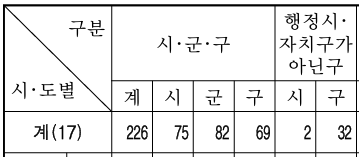

226+2+32-(자치구가 아닌 구를 둔 시군구) = 260-x = 250 (전국 제외)?


In [95]:
# Function to format numbers in millions
@FuncFormatter
def millions_formatter(x, pos):
    return f"{x/1e6:.2f}"


# Function to format numbers in millions
@FuncFormatter
def thousands_formatter(x, pos):
    return f"{int(x/1e3)}"


# Function to format numbers in millions
@FuncFormatter
def int_formatter(x, pos):
    return f"{int(x)}"


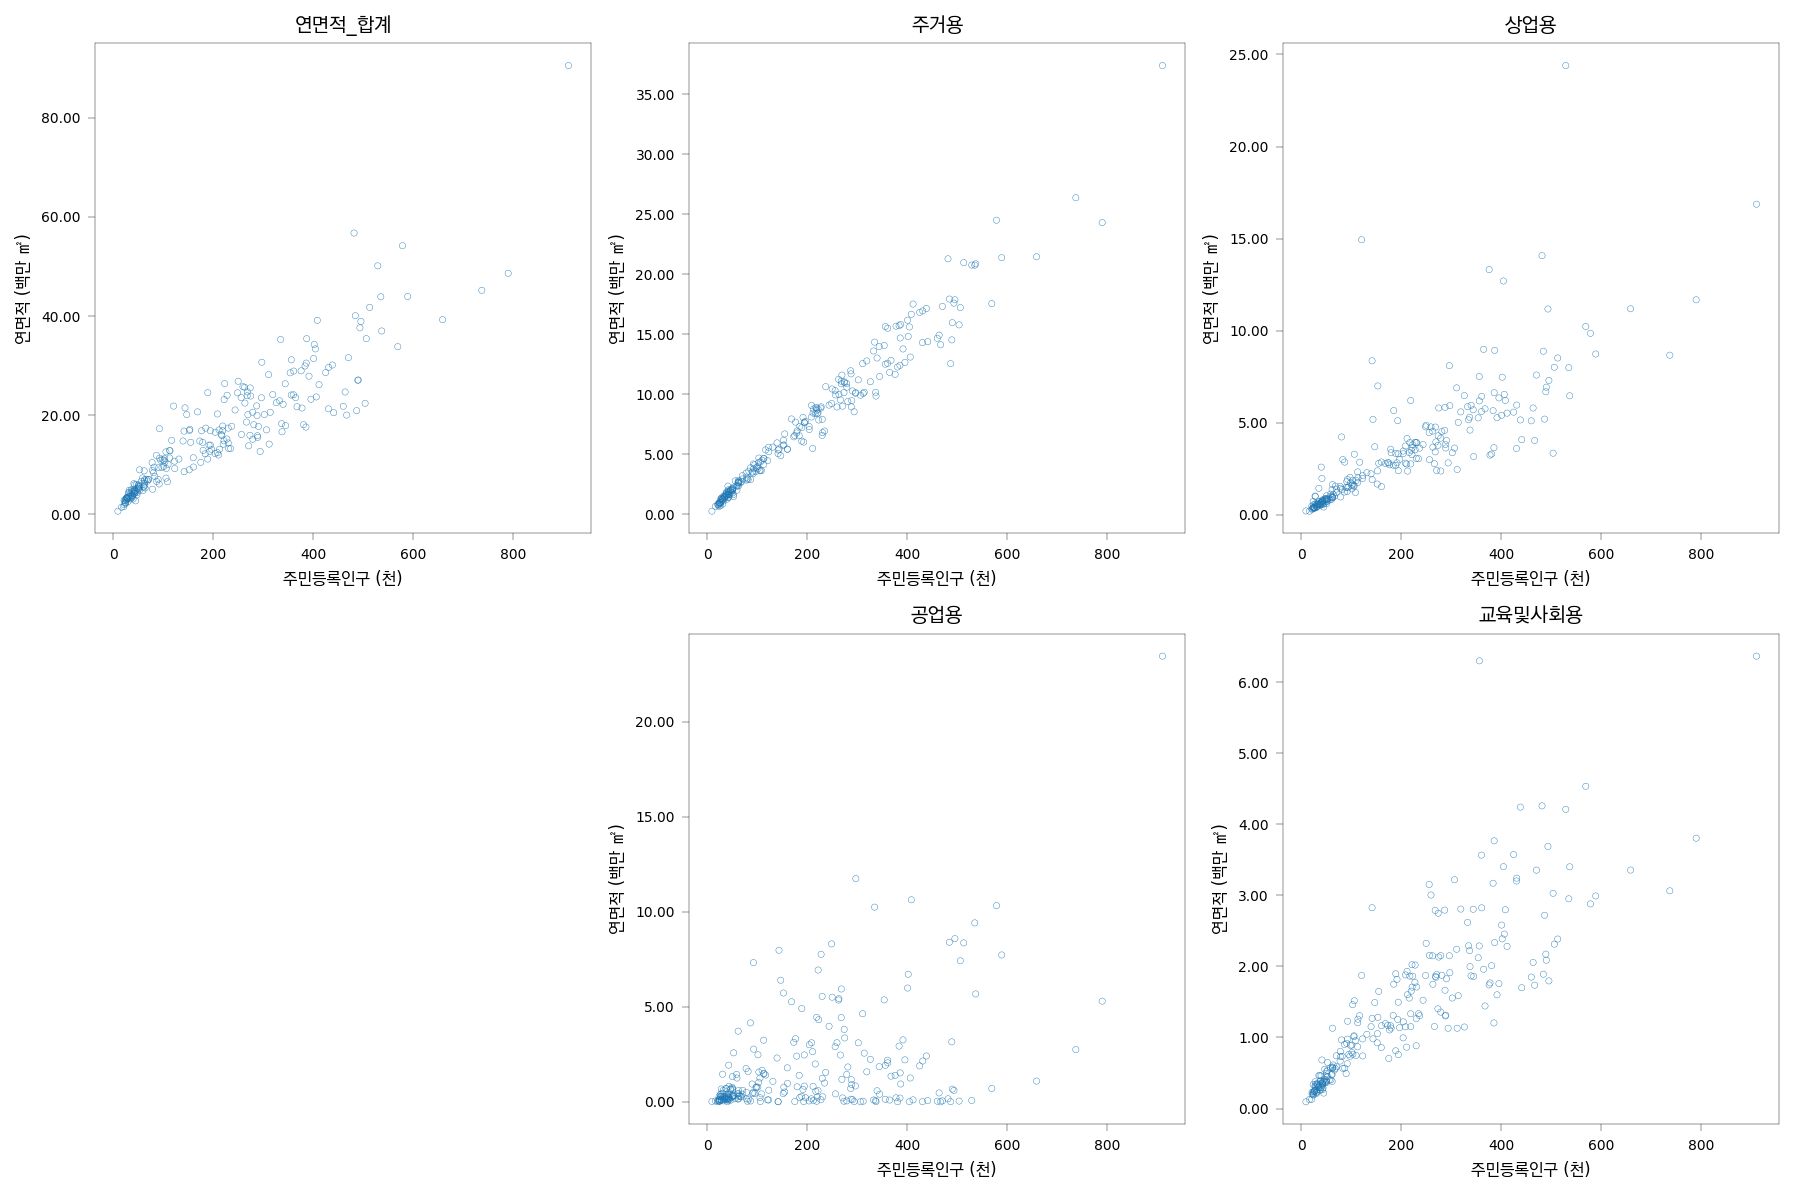

Figure saved as output\buildingstock\final_correlation\주민등록인구.svg
Figure saved as output\buildingstock\final_correlation\주민등록인구.png


In [99]:
def scatterplot_buildingstock(df, x_col):
    # Define the columns to show in y axis
    y_dict = {
        "A": "연면적_합계",
        "B": "주거용",
        "C": "상업용",
        "D": "공업용",
        "E": "교육및사회용",
    }

    # Define the mosaic layout
    mosaic = """
    ABC
    .DE
    """

    # Create the subplot mosaic
    fig, axd = plt.subplot_mosaic(mosaic, figsize=(12, 8))

    # Create scatterplots
    for key, y_col in y_dict.items():
        axd[key].scatter(df[x_col], df[y_col], edgecolors="C0", facecolors="none")
        axd[key].set_title(f"{y_col}")

        # Pick the formatter to x axes
        if df[x_col].max() > 1e6:
            x_suffix = " (백만)"
            x_formatter = millions_formatter

        elif df[x_col].max() > 1e3:
            x_suffix = " (천)"
            x_formatter = thousands_formatter
        else:
            x_suffix = ""
            x_formatter = int_formatter

        axd[key].set_xlabel(f"{x_col}{x_suffix}")
        axd[key].xaxis.set_major_formatter(x_formatter)

        axd[key].set_ylabel("연면적 (백만 ㎡)")
        axd[key].yaxis.set_major_formatter(millions_formatter)

    # Adjust the layout and show the plot
    plt.tight_layout()
    plt.show()

    # Create a new directory for saving the figure
    output_dir = Path("output/buildingstock/final_correlation/")
    output_dir.mkdir(exist_ok=True)

    # Save the figure
    filename = output_dir / f"{x_col}.svg"
    fig.savefig(filename)
    print(f"Figure saved as {filename}")
    filename = output_dir / f"{x_col}.png"
    fig.savefig(filename)
    print(f"Figure saved as {filename}")

    # Close the figure
    plt.close()


scatterplot_buildingstock(df3, "주민등록인구")


## 재고지표 산출 수행


In [101]:
y_cols = ["주거용", "상업용", "공업용", "교육및사회용"]
x_col = "주민등록인구"

df4 = df3.copy()
for y_col in y_cols:
    df4[f"재고지표_{y_col}"] = df4[y_col] / df4[x_col]

df4.info()


<class 'pandas.core.frame.DataFrame'>
Index: 250 entries, 11110 to 50130
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   시군구명         250 non-null    object 
 1   연면적_합계       250 non-null    Int64  
 2   주거용          250 non-null    Int64  
 3   상업용          250 non-null    Int64  
 4   공업용          250 non-null    Int64  
 5   교육및사회용       250 non-null    Int64  
 6   기타           250 non-null    Int64  
 7   주민등록인구       250 non-null    Int64  
 8   재고지표_주거용     250 non-null    Float64
 9   재고지표_상업용     250 non-null    Float64
 10  재고지표_공업용     250 non-null    Float64
 11  재고지표_교육및사회용  250 non-null    Float64
dtypes: Float64(4), Int64(7), object(1)
memory usage: 36.2+ KB


In [104]:
df4[
    ["재고지표_주거용", "재고지표_상업용", "재고지표_공업용", "재고지표_교육및사회용"]
].describe()


,재고지표_주거용,재고지표_상업용,재고지표_공업용,재고지표_교육및사회용
count,250.0,250.0,250.0,250.0
mean,38.255686,18.309497,9.740804,7.927106
std,4.839766,10.202616,11.638335,2.684119
min,25.755403,6.656025,0.006963,3.126371
25%,34.86609,14.308579,2.034226,6.096773
50%,38.840942,16.148427,5.614306,7.756575
75%,41.448695,18.433807,14.106637,9.392435
max,56.822518,124.044804,79.625638,19.985175


In [114]:
df4.loc["36110"]

시군구명                 세종특별자치시
연면적_합계                    29934347
주거용                         15697087
상업용                          5661425
공업용                          2935398
교육및사회용                    3169581
기타                            2470856
주민등록인구                     383591
재고지표_주거용               40.921416
재고지표_상업용               14.759014
재고지표_공업용                7.652416
재고지표_교육및사회용          8.262918
Name: 36110, dtype: object

In [ ]:
df4.to_csv("output/buildingstock/재고지표.csv", index=False, encoding="utf-8-sig")
